In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from collections import defaultdict

# Пример

Допустим, мы проводим эксперимент в онлайн магазине. Хотим что-то изменить на сайте магазина и ожидаем, что средняя выручка с пользователя увеличится. Эксперимент проводим одну неделю. Выбираем случайным образом две группы пользователей. Для пользователей контрольной группы ничего не меняем, для пользователей экспериментальной группы внедряем изменение. После окончания эксперимента считаем суммарную стоимость покупок для каждого пользователя и проверяем гипотезу о равенстве средних с помощью теста Стьюдента. Гипотезу проверяем на уровне значимости 0.05.

Для простоты рассмотрим группы из пяти пользователей. Результаты эксперимента приведены на картинке ниже. Среднее значение суммарной выручки с пользователя в экспериментальной группе больше на 40 рублей. Отличия статистически незначимые, p-value равно 0.87.

![before_experiment](https://habrastorage.org/r/w1560/getpro/habr/upload_files/1a9/c92/c91/1a9c92c9113cea633addb822c05c8862.png)

Просто применив тест Стьюдента, статистически значимых отличий найти не удалось. 

Посмотрим на данные о покупках пользователей до эксперимента:
![after_experiment](https://habrastorage.org/r/w1560/getpro/habr/upload_files/9df/ec6/8a3/9dfec68a391eb0502c74e94bee8aea83.png)

Из графиков видно, что пользователи до эксперимента каждую неделю совершали покупки на одну и ту же стоимость. Стоимость покупок пользователя во время эксперимента равна стоимости его покупок до эксперимента плюс эффект эксперимента. Средние стоимости покупок в группах А и Б до эксперимента в среднем совпадают, так как группы формировались случайно из одного распределения. В таком случае изначальная гипотеза о равенстве средних эквивалентна гипотезе о равенстве приращений во время эксперимента. Приращения для каждого пользователя подписаны на картинке справа от графиков.

Среднее значение приращений во время эксперимента в экспериментальной группе больше на 30 рублей. P-value равно 0.007, отличия статистически значимые. Благодаря переходу от стоимости покупок к приращениям, мы смогли обнаружить эффект. Это произошло из-за того, что точечная оценка эффекта осталась примерно той же, а разброс данных сильно уменьшился. Среднеквадратичное отклонение исходных данных равно 276, а приращений — 19.

# Теория
Ковариата — это метрика, скоррелированная с метрикой эксперимента, которая не зависит от эксперимента. В качестве ковариаты часто берут значения метрики эксперимента, посчитанные на периоде до эксперимента. Обозначим значения метрики эксперимента как Y, а значения ковариаты как X.

Суть метода CUPED состоит в переходе от метрики Yк метрике Y_{cuped}, которая вычисляется по формуле:
$$Y_{cuped} = Y - \theta X$$
где $\theta$ — некоторое действительное число.

Для каждого объекта в контрольной и экспериментальной группе нужно получить значения целевой метрики и ковариаты, и по ним для каждого объекта вычислить значение новой CUPED-метрики. Значения CUPED-метрики контрольной и экспериментальной групп будут подаваться в статистический критерий для проверки гипотезы.

Точечная оценка эффекта вычисляется как разница средних значений метрики в контрольной и экспериментальной группах. Если пользователи по группам распределяются случайно, и ковариата не зависит от эксперимента, то при замене исходной метрики на CUPED-метрику точечная оценка эффекта будет несмещённой.

Чем меньше дисперсия, тем больше чувствительность теста.

In [5]:
def generate_data(sample_size, corr, mean=2000, sigma=300):
    """Генерируем коррелированные данные исходной метрики и ковариаты.
    
    sample_size - размер выборки
    corr - корреляция исходной метрики с ковариатой
    mean - среднее значение исходной метрики
    sigma - стандартное отклонение исходной метрики

    return - pd.DataFrame со столбцами ['metric', 'covariate'],
        'metric' - значения исходной метрики,
        'covariate' - значения ковариаты.
    """
    means = np.array([mean, mean])
    cov = sigma ** 2 * np.array([[1, corr], [corr, 1]])
    data = np.random.multivariate_normal(means, cov, sample_size).astype(int)
    df = pd.DataFrame({'metric': data[:, 0], 'covariate': data[:, 1]})
    return df

def calculate_theta(metrics, covariates):
    """Вычисляем Theta.

    metrics - значения исходной метрики
    covariates - значения ковариаты

    return - theta.
    """
    covariance = np.cov(covariates, metrics)[0, 1]
    variance = covariates.var()
    theta = covariance / variance
    return theta

In [6]:
def check_ttest(df_control, df_pilot):
    """Проверяет гипотезу о равенстве средних с помощью t-test.

    return - pvalue.
    """
    values_control = df_control['metric'].values
    values_pilot = df_pilot['metric'].values
    _, pvalue = stats.ttest_ind(values_control, values_pilot)
    return pvalue

def check_cuped(df_control, df_pilot, df_theta):
    """Проверяет гипотезу о равенстве средних с использованием CUPED.
    
    df_control и df_pilot - данные контрольной и экспериментальной групп
    df_theta - данные для оценки theta

    return - pvalue.
    """
    theta = calculate_theta(df_theta['metric'], df_theta['covariate'])
    metric_cuped_control = df_control['metric'] - theta * df_control['covariate']
    metric_cuped_pilot = df_pilot['metric'] - theta * df_pilot['covariate']
    _, pvalue = stats.ttest_ind(metric_cuped_control, metric_cuped_pilot)
    return pvalue

In [24]:

sample_size = 1000      # размер групп
corr = 0.7              # корреляция ковариаты с целевой метрикой
effect = 20             # размер эффекта

df_control = generate_data(sample_size, corr)
df_pilot = generate_data(sample_size, corr)
df_pilot['metric'] += effect
df_theta = pd.concat([df_control, df_pilot])

pvalue_ind = check_ttest(df_control, df_pilot)
pvalue_cuped = check_cuped(df_control, df_pilot, df_theta)

print(f'pvalue_ind: {pvalue_ind}')
print(f'pvalue_cuped: {pvalue_cuped}')

pvalue_ind: 0.03303840942011045
pvalue_cuped: 0.0003823878273881497


Проверим корректность полученного критерия и сравним его с тестом Стьюдента. 

Для этого проведём большое количество симуляций оценки экспериментов и построим распределения p-value.

In [19]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    plt.figure(figsize=(16, 8))
    for key, pvalues in dict_pvalues.items():
        Y = [np.mean(pvalues < x) for x in X]
        plt.plot(X, Y, label=key)
    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

In [21]:
sample_size = 1000
corr = 0.7
effect = 20
dict_pvalues = defaultdict(list)

for _ in range(10000):
    df_control = generate_data(sample_size, corr)
    df_pilot = generate_data(sample_size, corr)
    df_theta = pd.concat([df_control, df_pilot])
    dict_pvalues['cuped A/A'].append(check_cuped(df_control, df_pilot, df_theta))
    df_pilot['metric'] += effect
    df_theta = pd.concat([df_control, df_pilot])
    dict_pvalues['cuped A/B'].append(check_cuped(df_control, df_pilot, df_theta))
    dict_pvalues['ttest A/B'].append(check_ttest(df_control, df_pilot))

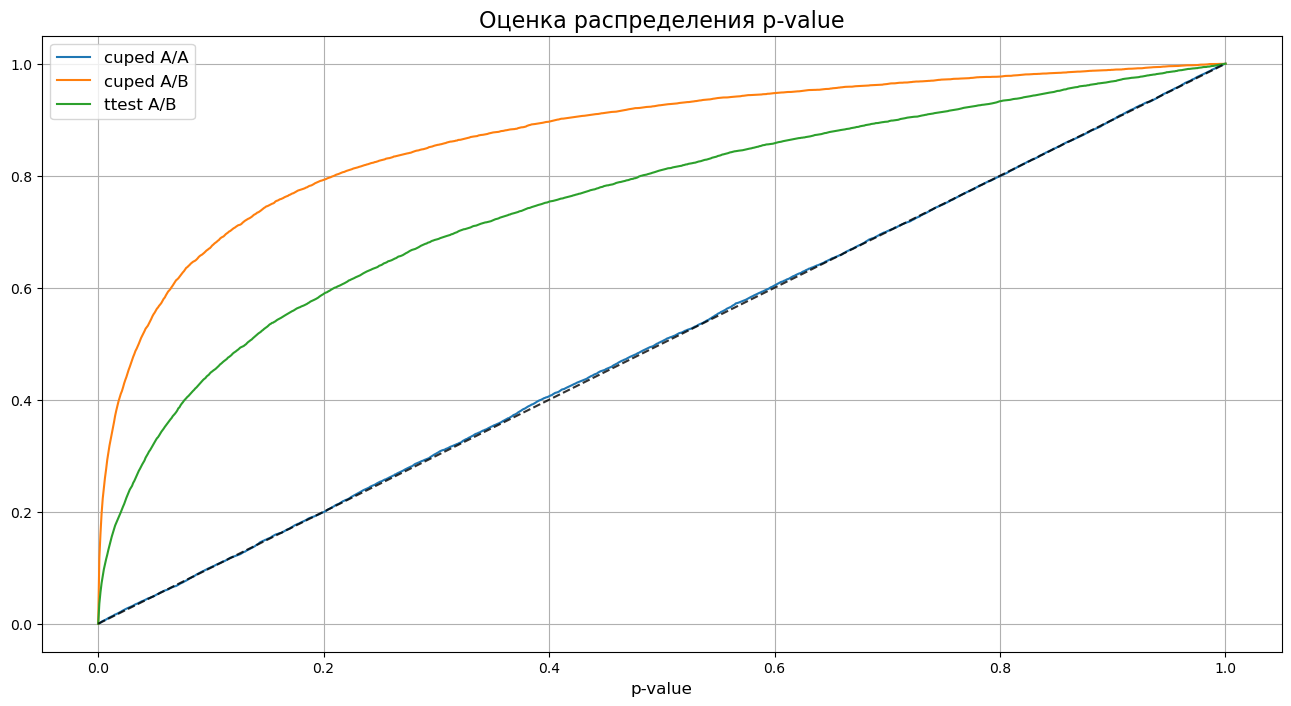

In [22]:
plot_pvalue_distribution(dict_pvalues)

CUPED работает корректно, p-value на А/А тестах распределены равномерно. 

CUPED имеет большую мощность, чем тест Стьюдента, p-value на А/Б тестах у CUPED выпукло сильнее. 